In [106]:
import pandas as pd

In [107]:
data = pd.read_csv("Product_Data.csv")

In [108]:
data.head()

,id,First_name,Last_name,Email,Contact,Gender,Products,Price,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,1.0,Kai,Reyna,kreyna0@cmu.edu,706784281-6,Female,Honor,2.79,NaN,NaN,NaN
1,2.0,Charlena,Yedall,cyedall1@nsw.gov.au,225704808-3,Female,Samsung,12.99,NaN,NaN,NaN
2,3.0,Ailina,Patters,apatters2@google.es,238096790-3,Genderqueer,Oppo,49.99,NaN,NaN,NaN
3,4.0,Jo ann,Crathorne,jcrathorne3@uiuc.edu,935636380-3,Female,Samsung,4.99,NaN,NaN,NaN
4,5.0,Baxie,Janc,bjanc4@newsvine.com,583438134-0,Male,Celkon,149.99,NaN,NaN,NaN


In [109]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539 entries, 0 to 538
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           500 non-null    float64
 1   First_name   500 non-null    object 
 2   Last_name    500 non-null    object 
 3   Email        500 non-null    object 
 4   Contact      500 non-null    object 
 5   Gender       500 non-null    object 
 6   Products     500 non-null    object 
 7   Price        500 non-null    float64
 8   Unnamed: 8   0 non-null      float64
 9   Unnamed: 9   0 non-null      float64
 10  Unnamed: 10  0 non-null      float64
dtypes: float64(5), object(6)
memory usage: 46.4+ KB


In [110]:
cols_drop = ['id']
data.drop(cols_drop, axis=1)
             

,First_name,Last_name,Email,Contact,Gender,Products,Price,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,Kai,Reyna,kreyna0@cmu.edu,706784281-6,Female,Honor,2.79,NaN,NaN,NaN
1,Charlena,Yedall,cyedall1@nsw.gov.au,225704808-3,Female,Samsung,12.99,NaN,NaN,NaN
2,Ailina,Patters,apatters2@google.es,238096790-3,Genderqueer,Oppo,49.99,NaN,NaN,NaN
3,Jo ann,Crathorne,jcrathorne3@uiuc.edu,935636380-3,Female,Samsung,4.99,NaN,NaN,NaN
4,Baxie,Janc,bjanc4@newsvine.com,583438134-0,Male,Celkon,149.99,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
534,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
535,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
536,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
537,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [111]:
missing_values = data.isnull().sum()
print(missing_values)

id              39
First_name      39
Last_name       39
Email           39
Contact         39
Gender          39
Products        39
Price           39
Unnamed: 8     539
Unnamed: 9     539
Unnamed: 10    539
dtype: int64


### MatPlotLib

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='Price'>

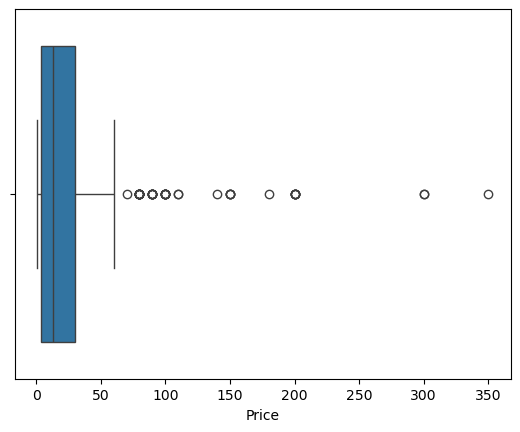

In [113]:
sns.boxplot(x = 'Price', data = data)

In [114]:
Q1 = data['Price'].quantile(0.25)
Q2 = data['Price'].quantile(0.75)

IQR = Q2 - Q1

print(IQR)

26.0


In [115]:
cleaned_data = data[(data['Price'] > Q1 - 1.5 * IQR) & (data['Price'] < Q2 + 1.5 * IQR)]
print(cleaned_data)

        id First_name    Last_name                     Email      Contact  \
0      1.0        Kai        Reyna           kreyna0@cmu.edu  706784281-6   
1      2.0   Charlena       Yedall       cyedall1@nsw.gov.au  225704808-3   
2      3.0     Ailina      Patters       apatters2@google.es  238096790-3   
3      4.0     Jo ann    Crathorne      jcrathorne3@uiuc.edu  935636380-3   
5      6.0   Matthieu       Hubach    mhubach5@indiegogo.com  413647171-8   
..     ...        ...          ...                       ...          ...   
495  496.0  Bernadine         Kose           bkosedr@nih.gov  211791198-6   
496  497.0     Jervis  Belderfield  jbelderfieldds@ocn.ne.jp  257460522-5   
497  498.0     Raquel    Doncaster  rdoncasterdt@t-online.de  562460650-8   
498  499.0       Dave  Mucklestone    dmucklestonedu@dot.gov  886027616-0   
499  500.0     Raynor     Fransoni      rfransonidv@wisc.edu  160772695-5   

          Gender  Products  Price  Unnamed: 8  Unnamed: 9  Unnamed: 10  
0 

<Axes: xlabel='Price'>

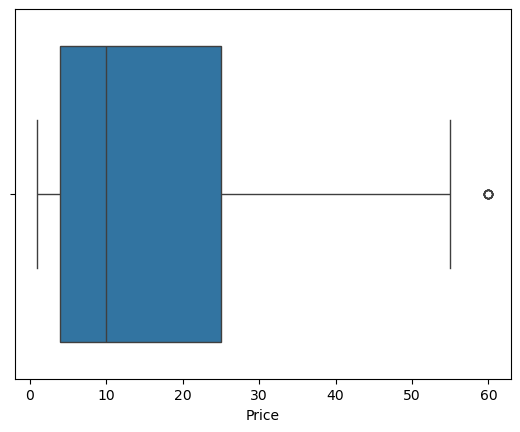

In [116]:
sns.boxplot(x = 'Price', data = cleaned_data)

In [117]:
lower_bound = 0
upper_bound = 100

data['Price'] = data['Price'].apply(lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x) )

<Axes: xlabel='Price'>

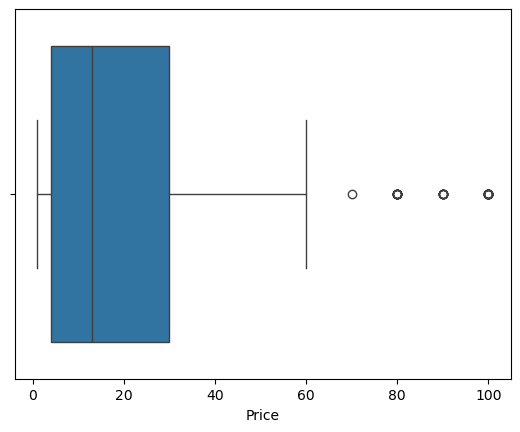

In [118]:
sns.boxplot(x = 'Price', data = data)

In [119]:
import numpy as np

In [120]:
data['Price'] = np.log(data['Price'] + 1)

<Axes: xlabel='Price'>

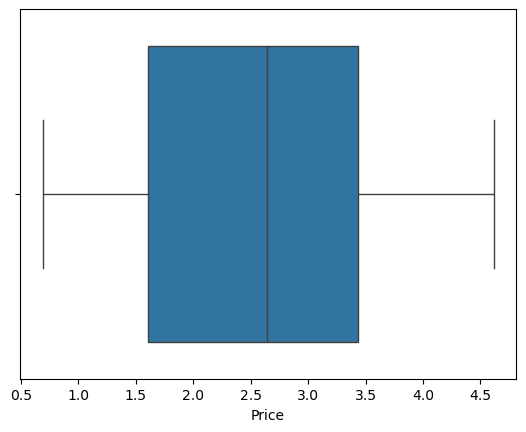

In [121]:
sns.boxplot(x = 'Price', data = data)

In [125]:
encoded_data = pd.get_dummies(data, columns = ['Contact'])
encoded_data.head()

,id,First_name,Last_name,Email,Gender,Products,Price,Unnamed: 8,Unnamed: 9,Unnamed: 10,...,Contact_984267372-3,Contact_987585216-3,Contact_988207373-5,Contact_990614892-6,Contact_991486958-0,Contact_992428803-3,Contact_992879122-8,Contact_993025798-5,Contact_994308667-X,Contact_996107582-X
0,1.0,Kai,Reyna,kreyna0@cmu.edu,Female,Honor,1.332366,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
1,2.0,Charlena,Yedall,cyedall1@nsw.gov.au,Female,Samsung,2.638343,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
2,3.0,Ailina,Patters,apatters2@google.es,Genderqueer,Oppo,3.931630,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
3,4.0,Jo ann,Crathorne,jcrathorne3@uiuc.edu,Female,Samsung,1.790091,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
4,5.0,Baxie,Janc,bjanc4@newsvine.com,Male,Celkon,4.615121,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
